Train size: 40000 samples, 10 features
Test size : 10000 samples, 10 features
Case 1: WITH Sales_Volume (leakage)
Accuracy: 1.0000
Macro F1-score: 1.0000

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3049
         Low       1.00      1.00      1.00      6951

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

[[3049    0]
 [   0 6951]]


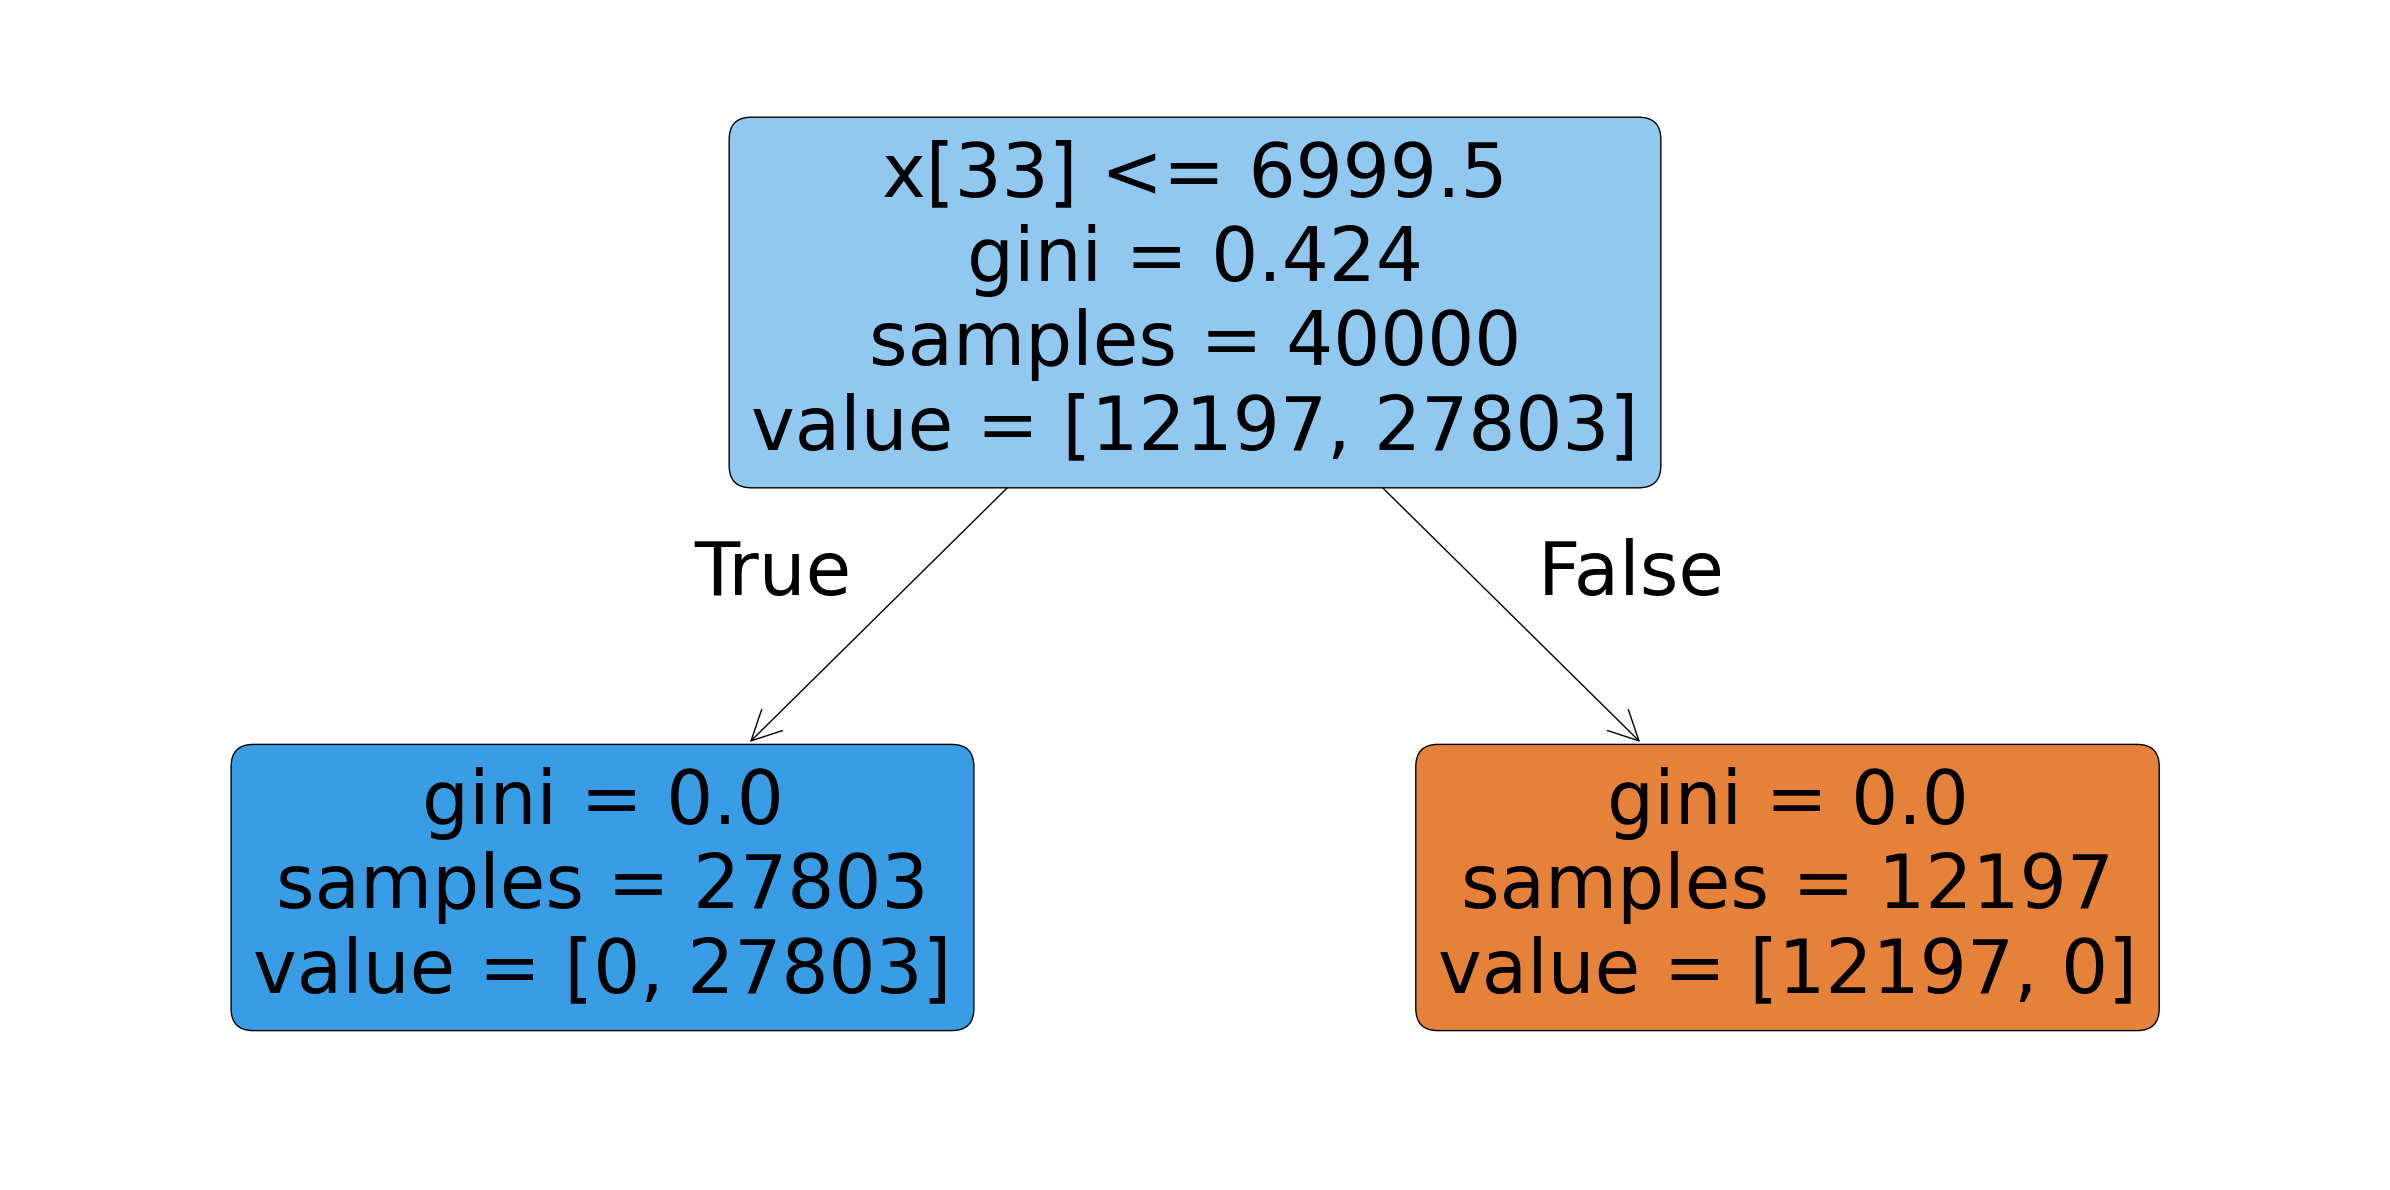

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

file_path = "/Users/diasnurmukhambetov/Desktop/group-project/BMW sales data (2010-2024) (1).csv"

df = pd.read_csv(file_path)

target_col = "Sales_Classification"

X = df.drop(columns=[target_col])
y = df[target_col]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test size : {X_test.shape[0]} samples, {X_test.shape[1]} features")

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=4,
    random_state=42,
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", clf),
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print("Case 1: WITH Sales_Volume (leakage)")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
plt.figure(figsize=(24, 12))
plot_tree(
    clf,
    filled=True,
    rounded=True
)
plt.tight_layout()
plt.show()
